Christian Thede
CNN Model

Notes:
1. Used AI for mounting and dealing with colab and google drive (and still had a ton of issues)
2. Model trained on MNIST
3. Hardware: T4 GPU from Colab

In [6]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Mount Google Drive
# Mount Google Drive if running in Colab; otherwise use the local working directory
try:
    from google.colab import drive
    drive.mount("/content/gdrive")
    DRIVE_ROOT = Path("/content/gdrive/MyDrive")
    OUTPUT_DIR = DRIVE_ROOT / "Colab Notebooks" / "Output"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    drive.mount("/content/gdrive")
except ModuleNotFoundError:
    DRIVE_ROOT = Path.cwd()


DRIVE_ROOT = Path("/content/gdrive/MyDrive")
OUTPUT_DIR = DRIVE_ROOT / "Colab Notebooks" / "Output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### Data
Load MNIST from torchvision, normalize pixel values, and split into batches

In [7]:
print("Preparing data...")
normalize_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5,), std=(0.5,))  # 1 channel for grayscale
])

# download data
train_dataset = torchvision.datasets.MNIST(root='./MNIST', train=True,  transform=normalize_transform, download=True)
test_dataset  = torchvision.datasets.MNIST(root='./MNIST', train=False, transform=normalize_transform, download=True)

# group images into batches
batch_size   = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=batch_size)

Preparing data...


100%|██████████| 9.91M/9.91M [00:00<00:00, 29.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 833kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 7.80MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


### Model
3 layer CNN
- conv layers extract features
- maxpool layers reduce spatial size (prevent overfitting)
- fully connected layers at the end to digit predictions

In [12]:
class CNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Conv2d(1,  32, kernel_size=3, padding=1), torch.nn.ReLU(), torch.nn.MaxPool2d(2),  # 28x28 -> 14x14
            torch.nn.Conv2d(32, 64, kernel_size=3, padding=1), torch.nn.ReLU(), torch.nn.MaxPool2d(2),  # 14x14 -> 7x7
            torch.nn.Conv2d(64, 64, kernel_size=3, padding=1), torch.nn.ReLU(), torch.nn.MaxPool2d(2),  # 7x7   -> 3x3
            torch.nn.Flatten(),
            torch.nn.Linear(64 * 3 * 3, 512), torch.nn.ReLU(),  # 64*3*3=576
            torch.nn.Linear(512, 10)  # outpus 1 score per digit classes
        )

    def forward(self, x):
        return self.model(x)

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Using device: {device}")
model = CNN().to(device)
print(torch.cuda.get_device_name(0))

Using device: cpu


AssertionError: Torch not compiled with CUDA enabled

### Train
Train for 30 epochs using Adam optimizer and a learning rate scheduler

Training...
Epoch 1/30: loss = 0.0404 | accuracy = 98.81%
Epoch 2/30: loss = 0.0342 | accuracy = 99.00%
Epoch 3/30: loss = 0.0310 | accuracy = 99.09%
Epoch 4/30: loss = 0.0289 | accuracy = 99.14%
Epoch 5/30: loss = 0.0273 | accuracy = 99.20%
Epoch 6/30: loss = 0.0229 | accuracy = 99.29%
Epoch 7/30: loss = 0.0214 | accuracy = 99.36%
Epoch 8/30: loss = 0.0207 | accuracy = 99.40%
Epoch 9/30: loss = 0.0201 | accuracy = 99.43%
Epoch 10/30: loss = 0.0195 | accuracy = 99.45%
Epoch 11/30: loss = 0.0174 | accuracy = 99.50%
Epoch 12/30: loss = 0.0169 | accuracy = 99.54%
Epoch 13/30: loss = 0.0166 | accuracy = 99.55%
Epoch 14/30: loss = 0.0163 | accuracy = 99.56%
Epoch 15/30: loss = 0.0161 | accuracy = 99.57%
Epoch 16/30: loss = 0.0150 | accuracy = 99.59%
Epoch 17/30: loss = 0.0148 | accuracy = 99.60%
Epoch 18/30: loss = 0.0146 | accuracy = 99.61%
Epoch 19/30: loss = 0.0145 | accuracy = 99.62%
Epoch 20/30: loss = 0.0144 | accuracy = 99.63%
Epoch 21/30: loss = 0.0138 | accuracy = 99.63%
Epoch 22/3

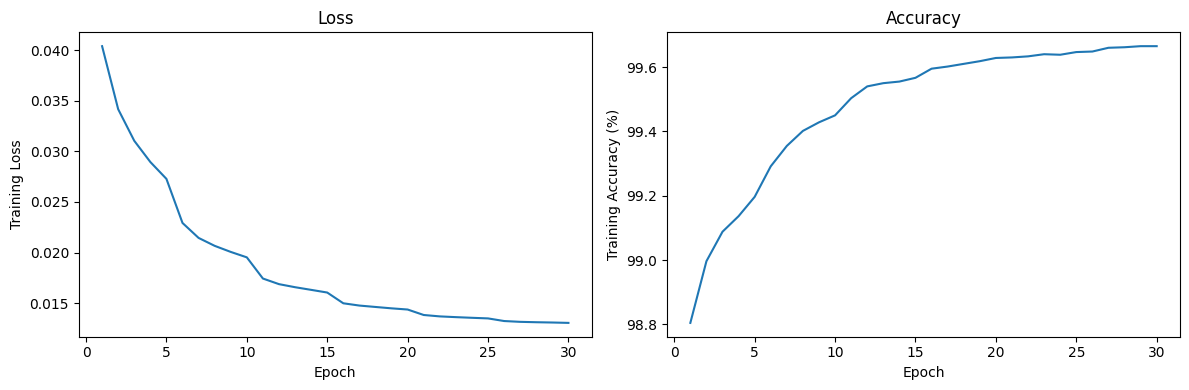

Model saved to /content/gdrive/MyDrive/Colab Notebooks/Output/mnist_cnn.pth


In [17]:
num_epochs    = 30
learning_rate = 0.001
weight_decay  = 0.001 # changed from .005 because it was plateauing early and the scheduler was pretty agressive
criterion     = torch.nn.CrossEntropyLoss()
optimizer     = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler     = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)  # learning rate decay
# with step size 5 and gamma .5 the learning rate is halved every 5 epochs

print("Training...")
train_loss_list = []
train_acc_list  = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}:", end=" ")
    train_loss    = 0
    correct       = 0
    total         = 0
    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct      += (predicted == labels).sum().item()
        total        += labels.size(0)

    train_loss_list.append(train_loss / len(train_loader))
    train_acc_list.append(100 * correct / total)
    print(f"loss = {train_loss_list[-1]:.4f} | accuracy = {train_acc_list[-1]:.2f}%")
    scheduler.step()  # added steps

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, num_epochs + 1), train_loss_list)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss")
ax1.set_title("Loss")

ax2.plot(range(1, num_epochs + 1), train_acc_list)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Training Accuracy (%)")
ax2.set_title("Accuracy")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png")
plt.show()

torch.save(model.state_dict(), OUTPUT_DIR / "mnist_cnn.pth")
print("Model saved to", OUTPUT_DIR / "mnist_cnn.pth")

Loading a Model

In [ ]:
# load a saved model from drive
loaded_model = CNN().to(device)
loaded_model.load_state_dict(torch.load(OUTPUT_DIR / "mnist_cnn.pth"))
loaded_model.eval()
print("Model loaded successfully from", OUTPUT_DIR / "mnist_cnn.pth")

### Test

Testing...
Test accuracy = 99.17%


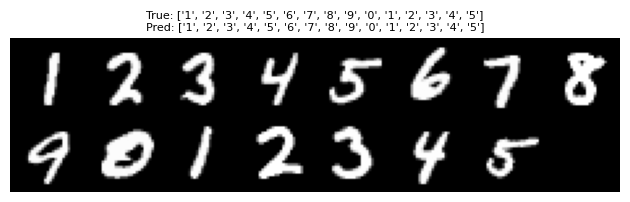

In [18]:
print("Testing...")
test_acc = 0
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, y_true = images.to(device), labels.to(device)
        outputs = model(images)
        _, y_pred = torch.max(outputs.data, 1)
        test_acc += (y_pred == y_true).sum().item()

print(f"Test accuracy = {100 * test_acc / len(test_dataset):.2f}%")

num_images   = 15
y_true_names = [names[y_true[i]] for i in range(num_images)]
y_pred_names = [names[y_pred[i]] for i in range(num_images)]

plt.imshow(np.transpose(
    torchvision.utils.make_grid(images[:num_images].cpu(), normalize=True, padding=1).numpy(),
    (1, 2, 0)
))
plt.title(f"True: {y_true_names}\nPred: {y_pred_names}", fontsize=8)
plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "test_predictions.png")
plt.show()